# 2.4 Seaborn

In [1]:
#Import Libraries

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from datetime import datetime as dt
import seaborn as sns

In [2]:
df=pd.read_parquet("df.parquet")

In [3]:
df.dtypes

ride_id               string[python]
rideable_type                 object
started_at                    object
ended_at                      object
start_station_name    string[python]
start_station_id      string[python]
end_station_name      string[python]
end_station_id        string[python]
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
date                  datetime64[ns]
avgTemp                      float64
trips                          int64
tripduration                 float64
dtype: object

### Plotting the Top 20 Starting Point Stations

In [4]:
top20=(df['start_station_name'].value_counts() .head(20) .sort_values()          )

In [6]:
#theme

plt.style.use("seaborn-v0_8-darkgrid")

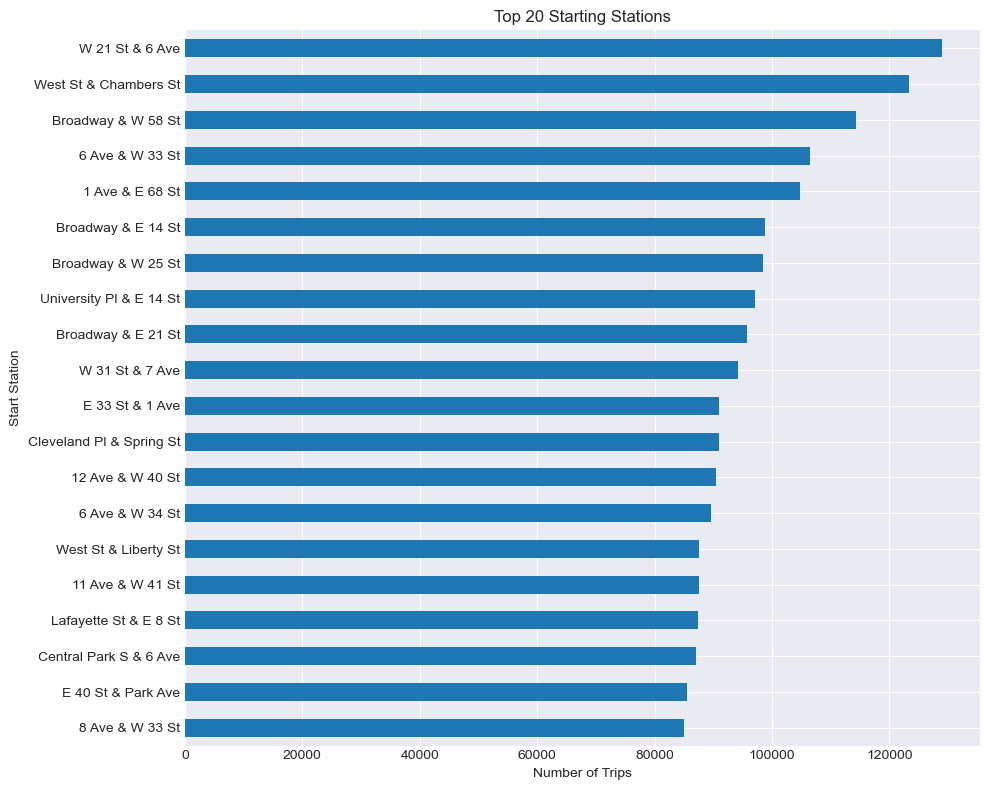

In [8]:
#plot 

top20.plot(kind="barh", figsize=(10, 8))
plt.xlabel("Number of Trips")
plt.ylabel("Start Station")
plt.title("Top 20 Starting Stations")
plt.tight_layout()
plt.show()

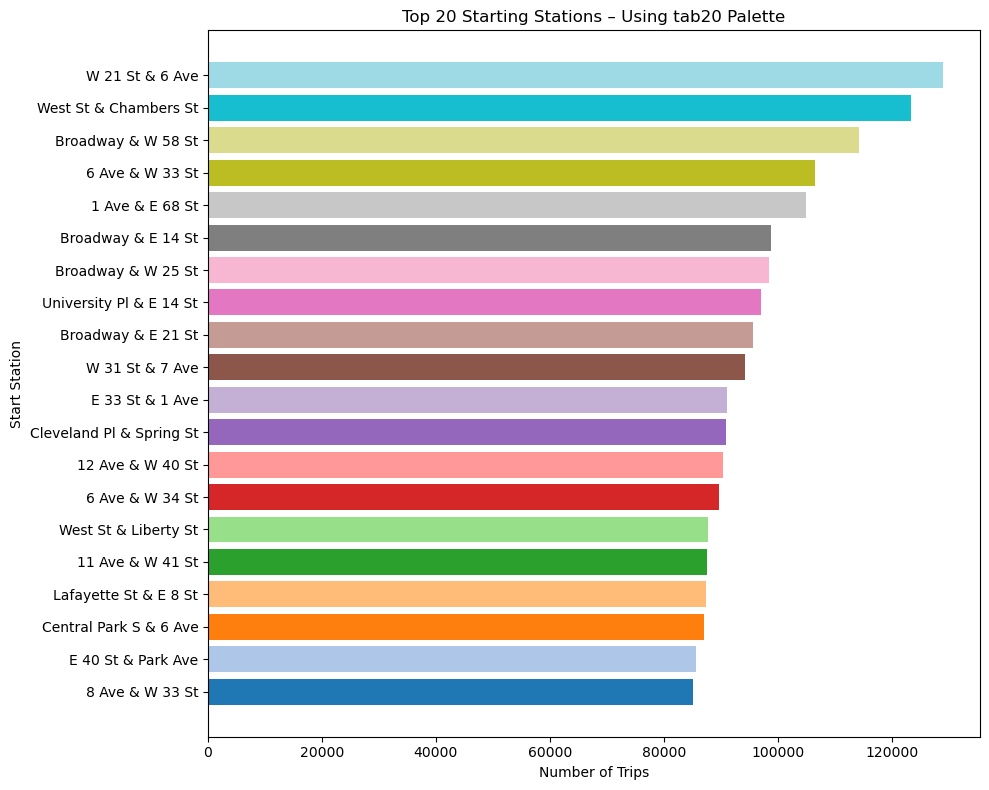

In [9]:
with plt.style.context("default"):  
    plt.figure(figsize=(10, 8))
    plt.barh(top20.index, top20.values, color=plt.cm.tab20.colors)
    plt.xlabel("Number of Trips")
    plt.ylabel("Start Station")
    plt.title("Top 20 Starting Stations – Using tab20 Palette")
    plt.tight_layout()
    plt.show()

### Notes

The default setting does not contain enough colors, if we would want to visualise every bar differently. I prefer the cleaner look of seaborn darkgrid but for a more attention drawing effect the tab20 is more suitable.

## Dual-Axis Plot Seaborn

In [12]:
sns.set_theme(style="darkgrid", palette="tab20")
plt.style.use("dark_background")

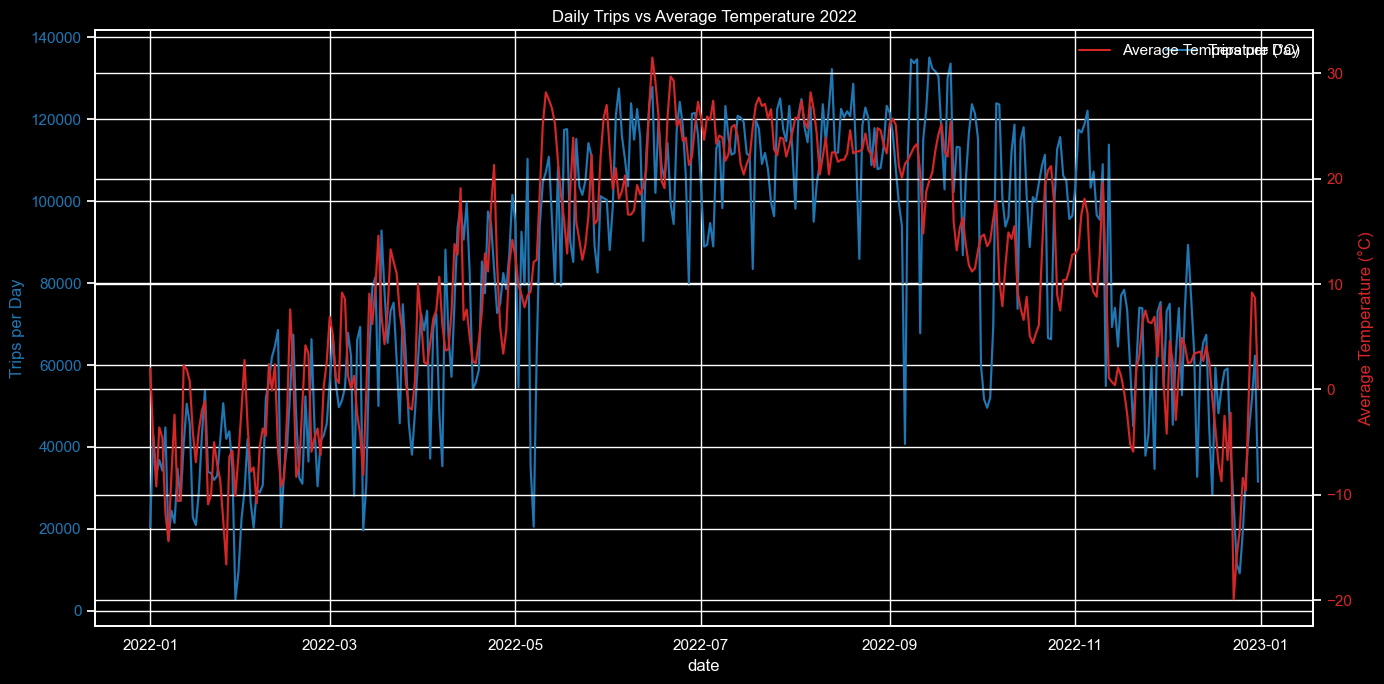

In [13]:
plt.figure(figsize=(14, 7))  #would have preferred different colors but I chose to stick to the theme
ax1=sns.lineplot(
    data=df,
    x="date",
    y="trips",
    color="tab:blue",
    label="Trips per Day"
)
ax1.set_ylabel("Trips per Day", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")   

ax2=ax1.twinx()
sns.lineplot(
    data=df,
    x="date",
    y="avgTemp",
    color="tab:red",
    label="Average Temperature (°C)",
    ax=ax2
)
ax2.set_ylabel("Average Temperature (°C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Daily Trips vs Average Temperature 2022")
plt.tight_layout()
plt.show()

## Box Plot Seaborn

In [14]:
df["tripduration"]=(pd.to_datetime(df["ended_at"]) - pd.to_datetime(df["started_at"])
).dt.total_seconds() / 60

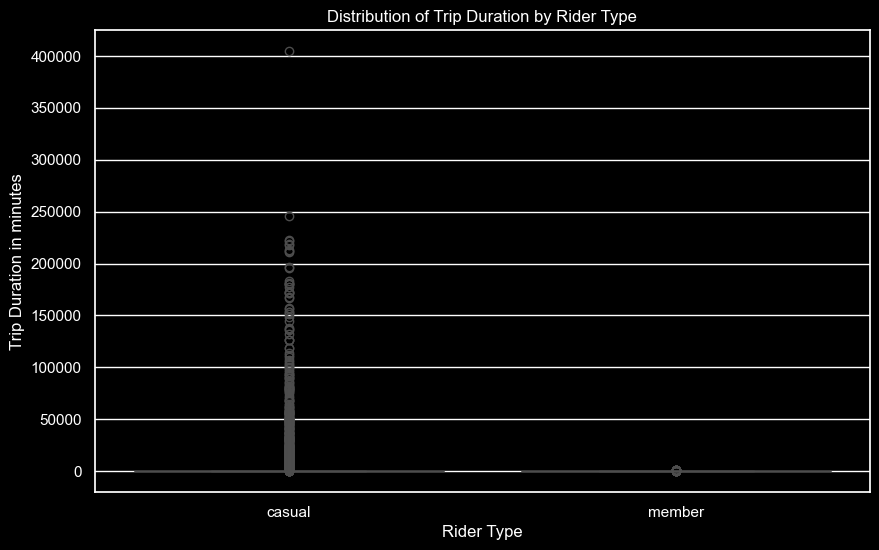

In [20]:
#plot

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="member_casual",
    y="tripduration",
    palette=["#FF00FF", "#39FF14"],
    hue="member_casual",
)

plt.title("Distribution of Trip Duration by Rider Type")
plt.xlabel("Rider Type")
plt.ylabel("Trip Duration in minutes")
plt.show()

### Notes

this plot shows a clear difference in trip duration patterns between casual and member riders. Casual riders display a very large number of extreme outliers, with some trips lasting many tens of thousands of minutes, which suggests unreturned bikes, system anomalies, or long recreational use. Members, on the other hand, have much more consistent and shorter trip durations with far fewer extreme values, indicating more predictable, routine commuting patterns.

## Facet Grid

In [21]:
#weekdays to determine which days/weekend days are the busiest

df["weekday"]=df["date"].dt.day_name()

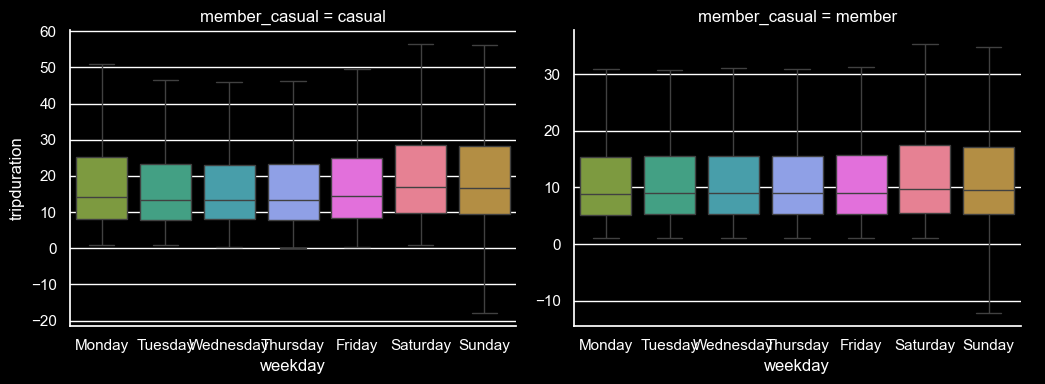

In [31]:
g = sns.FacetGrid(
    df,
    col="member_casual",
    col_wrap=2,
    height=4,
    aspect=1.3,
    sharey=False
)

g.map_dataframe(
    sns.boxplot,
    x="weekday",
    y="tripduration",
    hue="weekday",
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    palette="husl",
    dodge=False,     
    showfliers=False 
)

g.add_legend()
plt.show()

### Notes

The FacetGrid box plots compare trip durations for casual riders and members across weekdays. Both groups exhibit stable median trip durations throughout the week, but casual riders show consistently higher medians and more variability, indicating longer, more diverse trips. 
Weekend days see increased trip durations, particularly for casual riders, suggesting leisure use. In contrast, members maintain shorter, more consistent trips, reflecting a utilitarian use case. Overall, these insights reveal distinct behavioral patterns between user groups across the week.